In [43]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from PIL import Image
import random
import numpy as np
from eda import load_dataset_info, get_class_distribution

## 1. Dataset Overview

In [44]:
# Define dataset paths
dataset_paths = [
    "Dataset/Extracted data/Brain_Tumor_MRI_Dataset/Dataset",
    "Dataset/Extracted data/Brain_Tumor_MRI_Scans",
    "Dataset/Extracted data/BRATs_2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"
]

# Get distribution across all datasets
distribution = get_class_distribution(dataset_paths)

# Display overview
print("Available Datasets:\n")
for dataset_name, info in distribution.items():
    print(f"\n{dataset_name}")
    print(f"  Total Images: {info['total']}")
    print(f"  Number of Classes: {len(info['classes'])}")

Available Datasets:


Dataset
  Total Images: 10093
  Number of Classes: 4

Brain_Tumor_MRI_Scans
  Total Images: 7023
  Number of Classes: 4

MICCAI_BraTS2020_TrainingData
  Total Images: 1845
  Number of Classes: 369


## 2. Class Distribution

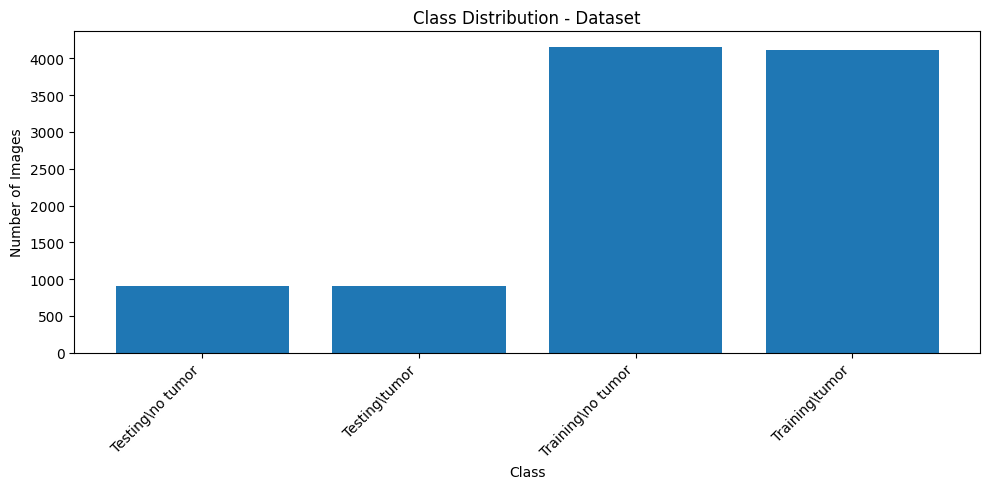


Dataset - Class Details:
  Testing\no tumor: 910 images
  Testing\tumor: 906 images
  Training\no tumor: 4160 images
  Training\tumor: 4117 images


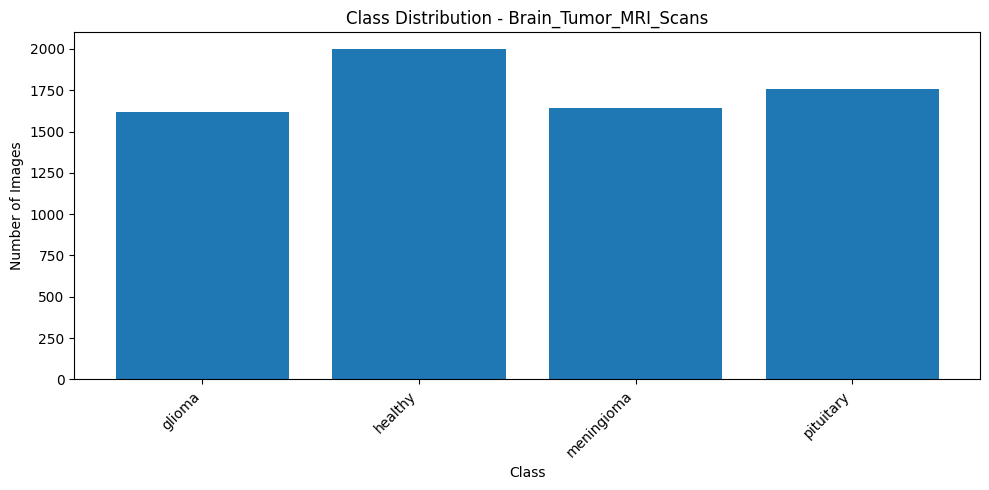


Brain_Tumor_MRI_Scans - Class Details:
  glioma: 1621 images
  healthy: 2000 images
  meningioma: 1645 images
  pituitary: 1757 images


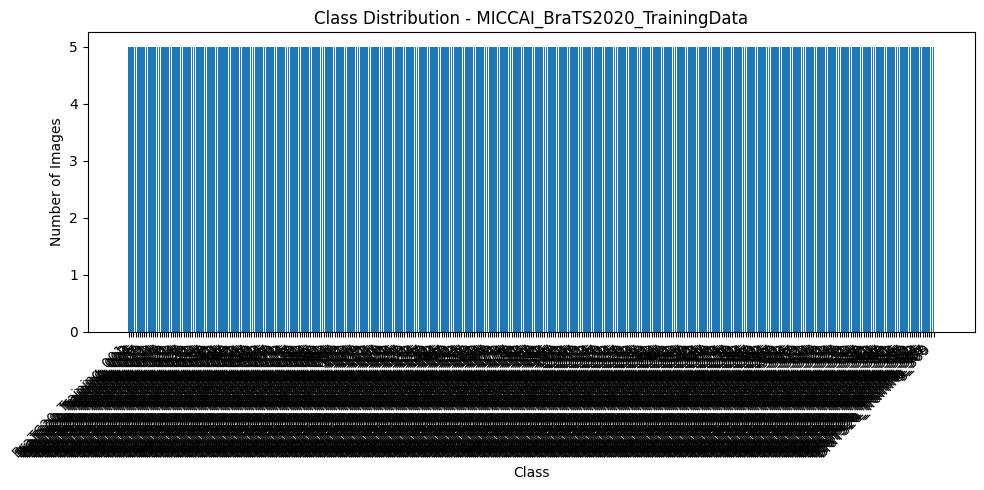


MICCAI_BraTS2020_TrainingData - Class Details:
  BraTS20_Training_001: 5 images
  BraTS20_Training_002: 5 images
  BraTS20_Training_003: 5 images
  BraTS20_Training_004: 5 images
  BraTS20_Training_005: 5 images
  BraTS20_Training_006: 5 images
  BraTS20_Training_007: 5 images
  BraTS20_Training_008: 5 images
  BraTS20_Training_009: 5 images
  BraTS20_Training_010: 5 images
  BraTS20_Training_011: 5 images
  BraTS20_Training_012: 5 images
  BraTS20_Training_013: 5 images
  BraTS20_Training_014: 5 images
  BraTS20_Training_015: 5 images
  BraTS20_Training_016: 5 images
  BraTS20_Training_017: 5 images
  BraTS20_Training_018: 5 images
  BraTS20_Training_019: 5 images
  BraTS20_Training_020: 5 images
  BraTS20_Training_021: 5 images
  BraTS20_Training_022: 5 images
  BraTS20_Training_023: 5 images
  BraTS20_Training_024: 5 images
  BraTS20_Training_025: 5 images
  BraTS20_Training_026: 5 images
  BraTS20_Training_027: 5 images
  BraTS20_Training_028: 5 images
  BraTS20_Training_029: 5 im

In [45]:
# Visualize class distribution for each dataset
for dataset_name, info in distribution.items():
    classes = info['classes']
    
    if classes:
        plt.figure(figsize=(10, 5))
        plt.bar(classes.keys(), classes.values())
        plt.title(f"Class Distribution - {dataset_name}")
        plt.xlabel("Class")
        plt.ylabel("Number of Images")
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Print details
        print(f"\n{dataset_name} - Class Details:")
        for class_name, count in classes.items():
            print(f"  {class_name}: {count} images")

## 3. Sample Visualization



Sample Images from: Dataset


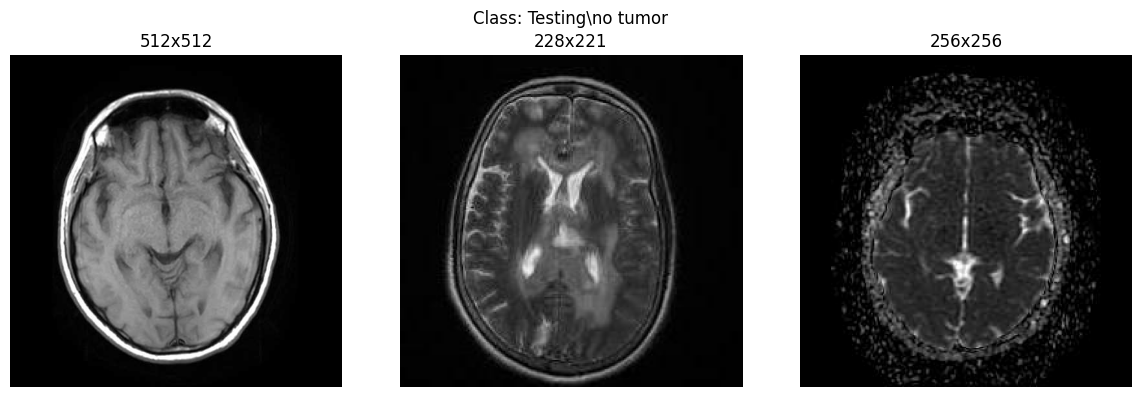

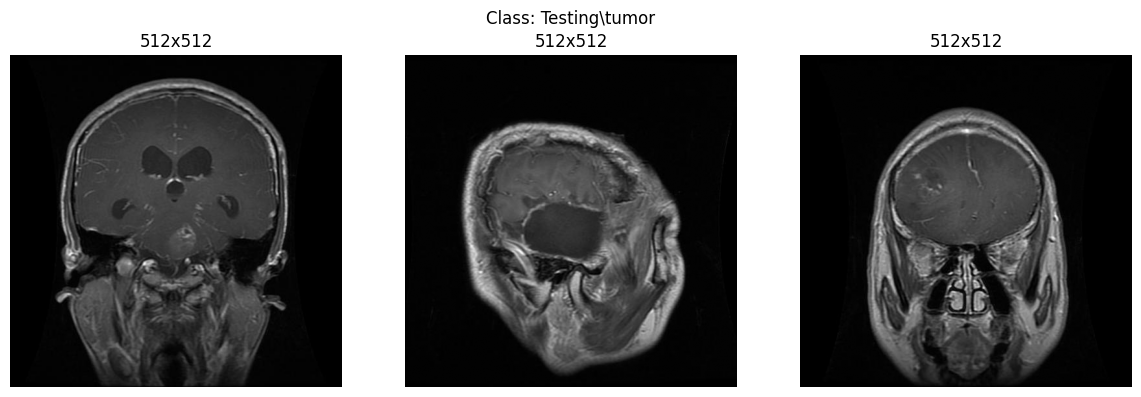

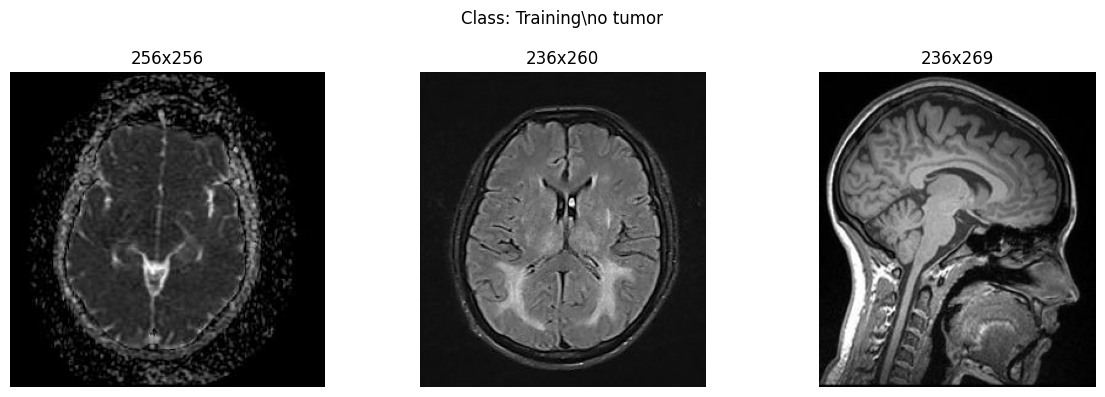

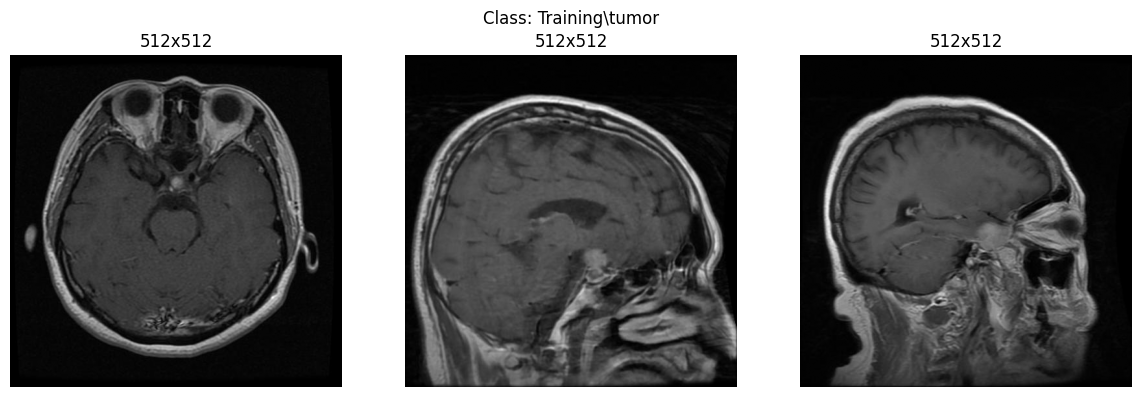



Sample Images from: Brain_Tumor_MRI_Scans


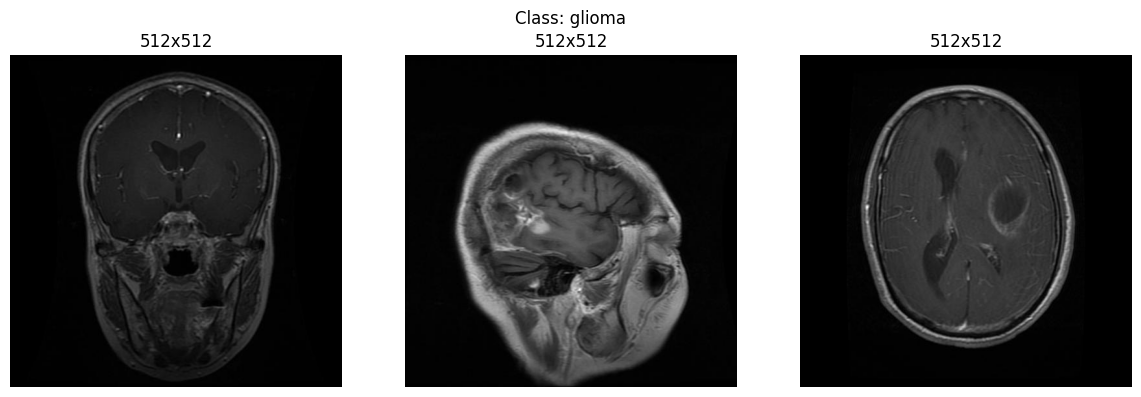

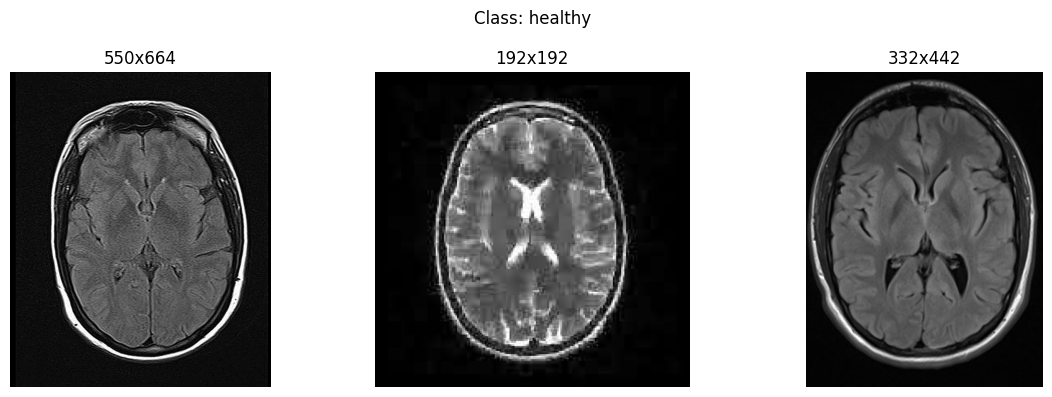

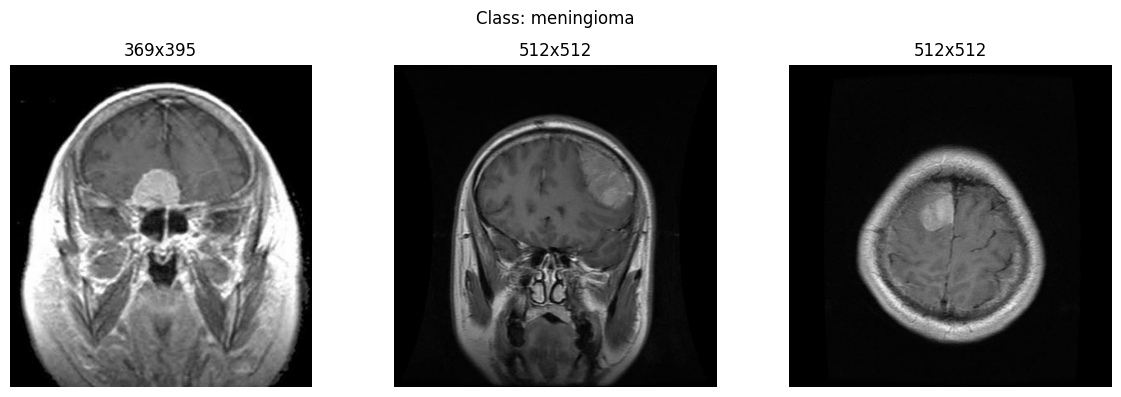

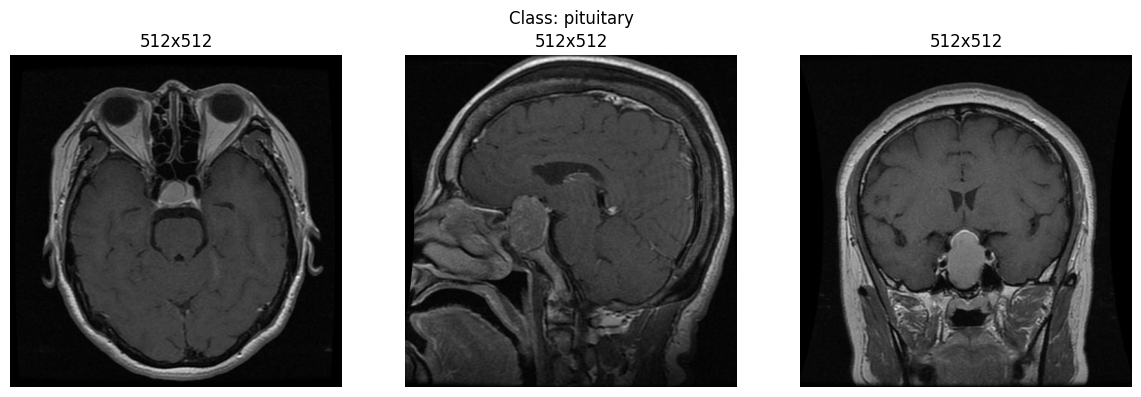

In [46]:
# Function to get sample images from a class
def get_sample_images(dataset_path, class_path, num_samples=3):
    """Get random sample images from a class directory."""
    full_path = Path(dataset_path) / class_path
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
    
    image_files = [f for f in full_path.glob('*') if f.suffix.lower() in image_extensions]
    
    if len(image_files) == 0:
        return []
    
    num_samples = min(num_samples, len(image_files))
    return random.sample(image_files, num_samples)


# Display sample images from each dataset
for dataset_path in dataset_paths[:2]:  # Focus on first two datasets for visualization
    dataset_info = load_dataset_info(dataset_path)
    
    if "error" in dataset_info:
        continue
    
    print(f"\n")
    print(f"Sample Images from: {dataset_info['dataset_name']}")

    
    # Get classes with images
    classes_with_images = [c for c, count in dataset_info['classes'].items() if count > 0]
    
    for class_name in classes_with_images[:4]:  # Limit to 4 classes per dataset
        sample_images = get_sample_images(dataset_path, class_name, num_samples=3)
        
        if sample_images:
            fig, axes = plt.subplots(1, len(sample_images), figsize=(12, 4))
            if len(sample_images) == 1:
                axes = [axes]
            
            for idx, img_path in enumerate(sample_images):
                img = Image.open(img_path)
                axes[idx].imshow(img, cmap='gray')
                axes[idx].axis('off')
                axes[idx].set_title(f"{img.size[0]}x{img.size[1]}")
            
            fig.suptitle(f"Class: {class_name}")
            plt.tight_layout()
            plt.show()

# Data Preprocessing

This section demonstrates the preprocessing pipeline including:
1. Image Standardization (Resize)
2. Normalization
3. Data Splitting (Train/Val/Test)
4. File Organization and Metadata Generation

In [47]:
from preprocessing import (
    resize_image, 
    normalize_image, 
    create_data_split, 
    organize_processed_data,
    preprocess_and_save,
    get_image_statistics
)

## 4. Image Standardization (Resize)

Original size: (512, 512)
Resized size (no aspect ratio): (224, 224)
Resized size (with aspect ratio): (224, 224)


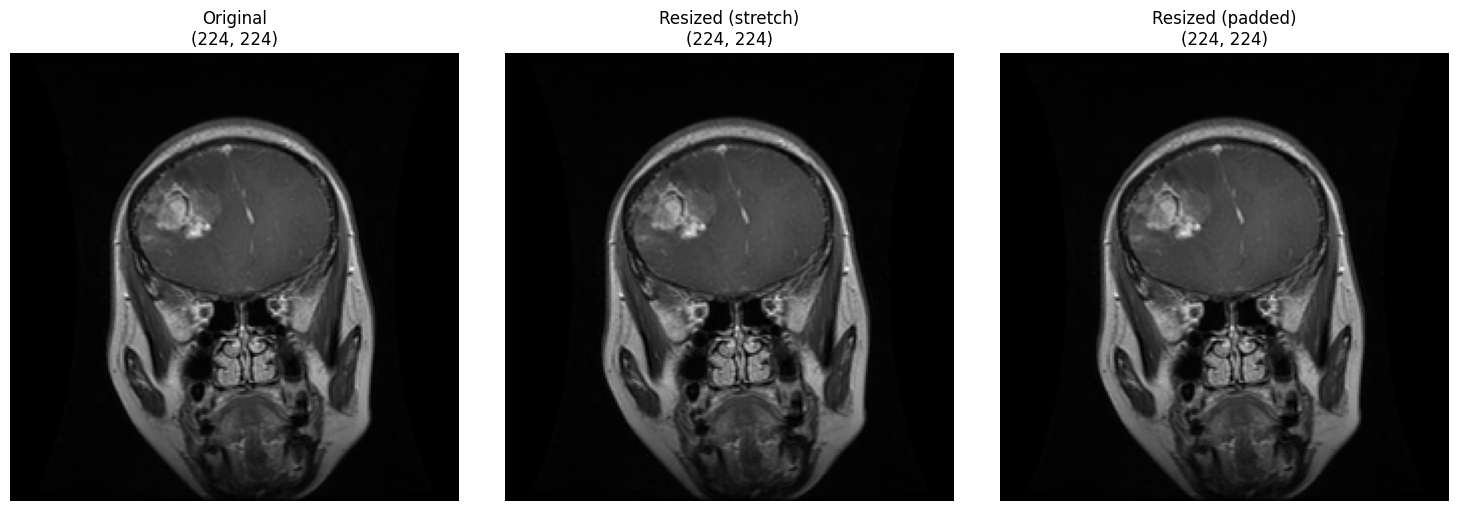

In [48]:
# Test resize function with a sample image
sample_dataset = "Dataset/Extracted data/Brain_Tumor_MRI_Dataset/Dataset/Training"
sample_class = "tumor"
sample_path = Path(sample_dataset) / sample_class

# Get first image
sample_image_path = list(sample_path.glob('*.jpg'))[0]
sample_img = Image.open(sample_image_path)

print(f"Original size: {sample_img.size}")

# Resize without maintaining aspect ratio
resized_img = resize_image(sample_img, target_size=(224, 224), keep_aspect_ratio=False)
print(f"Resized size (no aspect ratio): {resized_img.size}")

# Resize with aspect ratio maintained
resized_img_ar = resize_image(sample_img, target_size=(224, 224), keep_aspect_ratio=True)
print(f"Resized size (with aspect ratio): {resized_img_ar.size}")

# Display comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_img, cmap='gray')
axes[0].set_title(f"Original\n{sample_img.size}")
axes[0].axis('off')

axes[1].imshow(resized_img, cmap='gray')
axes[1].set_title(f"Resized (stretch)\n{resized_img.size}")
axes[1].axis('off')

axes[2].imshow(resized_img_ar, cmap='gray')
axes[2].set_title(f"Resized (padded)\n{resized_img_ar.size}")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 5. Z-score Normalization (Thesis Standard)

Original - Range: [0, 253]
Original - Mean: 31.38, Std: 43.32

Z-score - Range: [-0.724, 5.116]
Z-score - Mean: -0.000000, Std: 1.000
✓ Mean ≈ 0, Std ≈ 1 (confirms proper standardization)


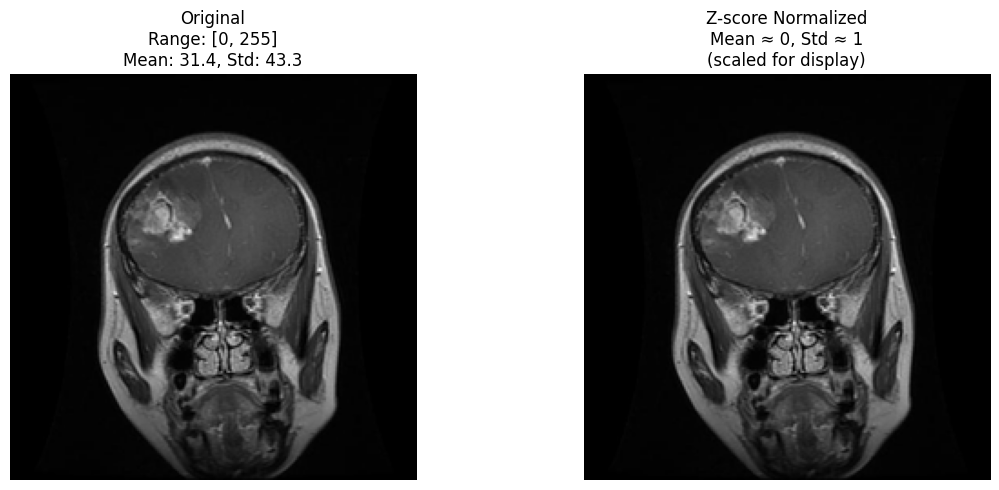

In [49]:
# Reload preprocessing to get zscore_normalize
import importlib
importlib.reload(preprocessing)
from preprocessing import zscore_normalize

# Test Z-score normalization
img_array = np.array(resized_img)

# Apply Z-score normalization (per-channel)
img_zscore = zscore_normalize(img_array, per_channel=True)

print(f"Original - Range: [{img_array.min()}, {img_array.max()}]")
print(f"Original - Mean: {img_array.mean():.2f}, Std: {img_array.std():.2f}")

print(f"\nZ-score - Range: [{img_zscore.min():.3f}, {img_zscore.max():.3f}]")
print(f"Z-score - Mean: {img_zscore.mean():.6f}, Std: {img_zscore.std():.3f}")
print("✓ Mean ≈ 0, Std ≈ 1 (confirms proper standardization)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img_array, cmap='gray')
axes[0].set_title(f"Original\nRange: [0, 255]\nMean: {img_array.mean():.1f}, Std: {img_array.std():.1f}")
axes[0].axis('off')

# For visualization, scale Z-score normalized back to [0, 1]
img_zscore_vis = (img_zscore - img_zscore.min()) / (img_zscore.max() - img_zscore.min())
axes[1].imshow(img_zscore_vis, cmap='gray')
axes[1].set_title(f"Z-score Normalized\nMean ≈ 0, Std ≈ 1\n(scaled for display)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 6. Data Splitting (Train/Val/Test)

Data Split Summary:

TRAIN SET:
  Total images: 5793
  Class distribution:
    no tumor: 2912 (50.3%)
    tumor: 2881 (49.7%)

VAL SET:
  Total images: 1242
  Class distribution:
    no tumor: 624 (50.2%)
    tumor: 618 (49.8%)

TEST SET:
  Total images: 1242
  Class distribution:
    no tumor: 624 (50.2%)
    tumor: 618 (49.8%)


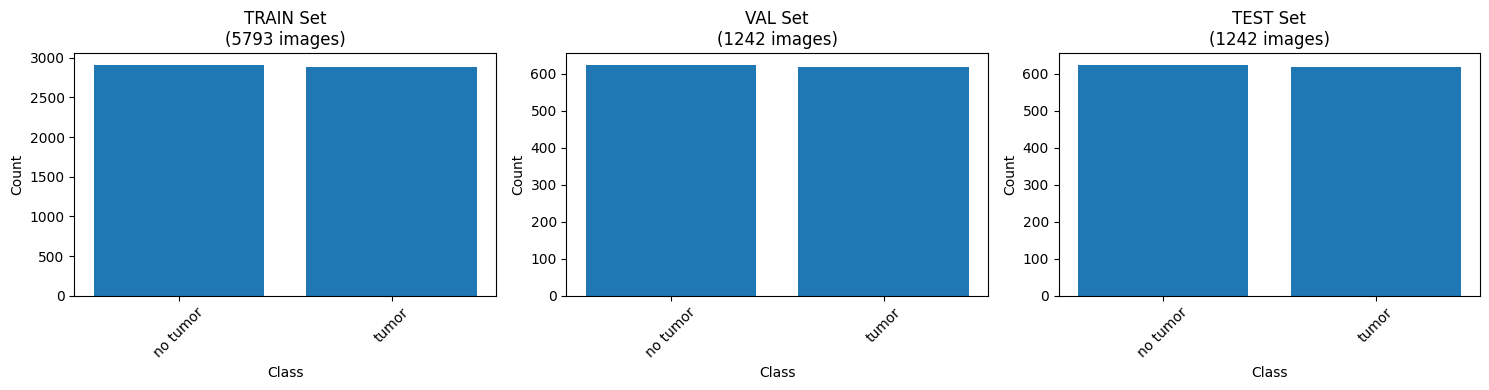

In [50]:
# Create train/val/test splits for Brain_Tumor_MRI_Dataset
dataset_to_split = "Dataset/Extracted data/Brain_Tumor_MRI_Dataset/Dataset/Training"

splits = create_data_split(
    dataset_path=dataset_to_split,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15,
    random_state=42
)

# Display split information
print("Data Split Summary:")
print("="*50)
for split_name, df in splits.items():
    print(f"\n{split_name.upper()} SET:")
    print(f"  Total images: {len(df)}")
    print(f"  Class distribution:")
    for class_name, count in df['class_name'].value_counts().items():
        print(f"    {class_name}: {count} ({count/len(df)*100:.1f}%)")

# Visualize split distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (split_name, df) in enumerate(splits.items()):
    class_counts = df['class_name'].value_counts()
    axes[idx].bar(class_counts.index, class_counts.values)
    axes[idx].set_title(f"{split_name.upper()} Set\n({len(df)} images)")
    axes[idx].set_xlabel("Class")
    axes[idx].set_ylabel("Count")
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 7. File Organization and Metadata Generation

In [51]:
# Organize data and create metadata
output_directory = "Dataset/preprocessed_data"

metadata_paths = organize_processed_data(
    splits=splits,
    output_dir=output_directory,
    copy_files=False  # Set to False to only create metadata
)

print("Metadata files created:")
print("="*50)
for split_name, path in metadata_paths.items():
    print(f"{split_name}: {path}")

# Display sample of combined metadata
combined_metadata = pd.read_csv(metadata_paths['combined'])
print(f"\n\nCombined Metadata Summary:")
print(f"Total entries: {len(combined_metadata)}")
print(f"\nFirst few rows:")
print(combined_metadata.head(10))

print(f"\n\nSplit Distribution:")
print(combined_metadata['split'].value_counts())

print(f"\n\nClass Distribution by Split:")
print(pd.crosstab(combined_metadata['split'], combined_metadata['class_name']))

Metadata files created:
train: Dataset\preprocessed_data\train_metadata.csv
val: Dataset\preprocessed_data\val_metadata.csv
test: Dataset\preprocessed_data\test_metadata.csv
combined: Dataset\preprocessed_data\all_metadata.csv


Combined Metadata Summary:
Total entries: 8277

First few rows:
                                           file_path     label class_name  \
0  Dataset\Extracted data\Brain_Tumor_MRI_Dataset...  no tumor   no tumor   
1  Dataset\Extracted data\Brain_Tumor_MRI_Dataset...     tumor      tumor   
2  Dataset\Extracted data\Brain_Tumor_MRI_Dataset...     tumor      tumor   
3  Dataset\Extracted data\Brain_Tumor_MRI_Dataset...  no tumor   no tumor   
4  Dataset\Extracted data\Brain_Tumor_MRI_Dataset...     tumor      tumor   
5  Dataset\Extracted data\Brain_Tumor_MRI_Dataset...     tumor      tumor   
6  Dataset\Extracted data\Brain_Tumor_MRI_Dataset...  no tumor   no tumor   
7  Dataset\Extracted data\Brain_Tumor_MRI_Dataset...     tumor      tumor   
8  Dataset\Ext

## 8. Complete Preprocessing Pipeline Example

In [52]:
# Example: Preprocess and save a batch of images with Z-score normalization
# This demonstrates the complete pipeline

# Select a small sample for demonstration
sample_size = 5
sample_metadata = combined_metadata.sample(n=sample_size, random_state=42)

print("Processing sample images with Z-score normalization...")
print("="*50)

for idx, row in sample_metadata.iterrows():
    input_path = row['file_path']
    
    # Create output path
    relative_filename = Path(input_path).name
    output_path = Path(output_directory) / row['split'] / row['class_name'] / relative_filename
    
    # Preprocess and save (now uses Z-score by default)
    success = preprocess_and_save(
        image_path=input_path,
        output_path=output_path,
        target_size=(224, 224)
    )
    
    if success:
        print(f"✓ Processed: {relative_filename} -> {row['split']}/{row['class_name']}/")
    else:
        print(f"✗ Failed: {relative_filename}")

print(f"\n\nPreprocessed images saved to: {output_directory}")
print("Note: All images now use Z-score normalization (per-channel)")
print("\nDirectory structure:")
for split in ['train', 'val', 'test']:
    split_dir = Path(output_directory) / split
    if split_dir.exists():
        print(f"\n{split}/")
        for class_dir in split_dir.iterdir():
            if class_dir.is_dir():
                num_files = len(list(class_dir.glob('*')))
                print(f"  {class_dir.name}/ ({num_files} files)")

Processing sample images with Z-score normalization...
✓ Processed: Tr-gl_0685.jpg -> train/tumor/
✓ Processed: Tr-pi_0118.jpg -> train/tumor/
✓ Processed: Tr-me_0645.jpg -> val/tumor/
✓ Processed: Tr-gl_0540.jpg -> train/tumor/
✓ Processed: Tr-pi_0851.jpg -> train/tumor/


Preprocessed images saved to: Dataset/preprocessed_data
Note: All images now use Z-score normalization (per-channel)

Directory structure:

train/
  tumor/ (4 files)

val/
  tumor/ (1 files)

test/
✓ Processed: Tr-pi_0118.jpg -> train/tumor/
✓ Processed: Tr-me_0645.jpg -> val/tumor/
✓ Processed: Tr-gl_0540.jpg -> train/tumor/
✓ Processed: Tr-pi_0851.jpg -> train/tumor/


Preprocessed images saved to: Dataset/preprocessed_data
Note: All images now use Z-score normalization (per-channel)

Directory structure:

train/
  tumor/ (4 files)

val/
  tumor/ (1 files)

test/


## Batch Preprocessing All Images

In [53]:
# Reload preprocessing module to get updated function
import importlib
import preprocessing
importlib.reload(preprocessing)
from preprocessing import batch_preprocess_images

# Process all images with Z-score normalization
metadata_file = os.path.join(output_directory, 'all_metadata.csv')
print("Starting batch preprocessing with Z-score normalization...")
print(f"This will process all {len(pd.read_csv(metadata_file))} images\n")

stats = batch_preprocess_images(
    metadata_path=metadata_file,
    output_base_dir=output_directory,
    target_size=(224, 224)
)

print(f"\n{'='*50}")
print(f"Preprocessing Statistics:")
print(f"{'='*50}")
print(f"Total images: {stats['total']}")
print(f"Successfully processed: {stats['success']}")
print(f"Failed: {stats['failed']}")
print(f"\n✓ All images normalized using Z-score (mean≈0, std≈1)")
if stats['failed'] > 0:
    print(f"\nFailed files (first 10):")
    for file in stats['failed_files'][:10]:
        print(f"  - {file}")

Starting batch preprocessing with Z-score normalization...
This will process all 8277 images

This will process all 8277 images

Processed 500/8277 images...
Processed 500/8277 images...
Processed 1000/8277 images...
Processed 1000/8277 images...
Processed 1500/8277 images...
Processed 1500/8277 images...
Processed 2000/8277 images...
Processed 2000/8277 images...
Processed 2500/8277 images...
Processed 2500/8277 images...
Processed 3000/8277 images...
Processed 3000/8277 images...
Processed 3500/8277 images...
Processed 3500/8277 images...
Processed 4000/8277 images...
Processed 4000/8277 images...
Processed 4500/8277 images...
Processed 4500/8277 images...
Processed 5000/8277 images...
Processed 5000/8277 images...
Processed 5500/8277 images...
Processed 5500/8277 images...
Processed 6000/8277 images...
Processed 6000/8277 images...
Processed 6500/8277 images...
Processed 6500/8277 images...
Processed 7000/8277 images...
Processed 7000/8277 images...
Processed 7500/8277 images...
Pro

## Data Augmentation Pipeline (Domain Generalization)

In [55]:
# Reload preprocessing to get augmentation functions
import importlib
importlib.reload(preprocessing)
from preprocessing import (
    augment_rotation, 
    augment_flip, 
    augment_zoom, 
    augment_intensity,
    augment_elastic_deform,
    apply_augmentation_pipeline
)

# Load a sample image for augmentation testing
sample_img_path = list(Path(dataset_paths[0]).rglob('*.jpg'))[0]
original_img = Image.open(sample_img_path).resize((224, 224))

print(f"Testing augmentation pipeline on: {sample_img_path.name}")
print("="*60)

Testing augmentation pipeline on: MR0001 (10).jpg


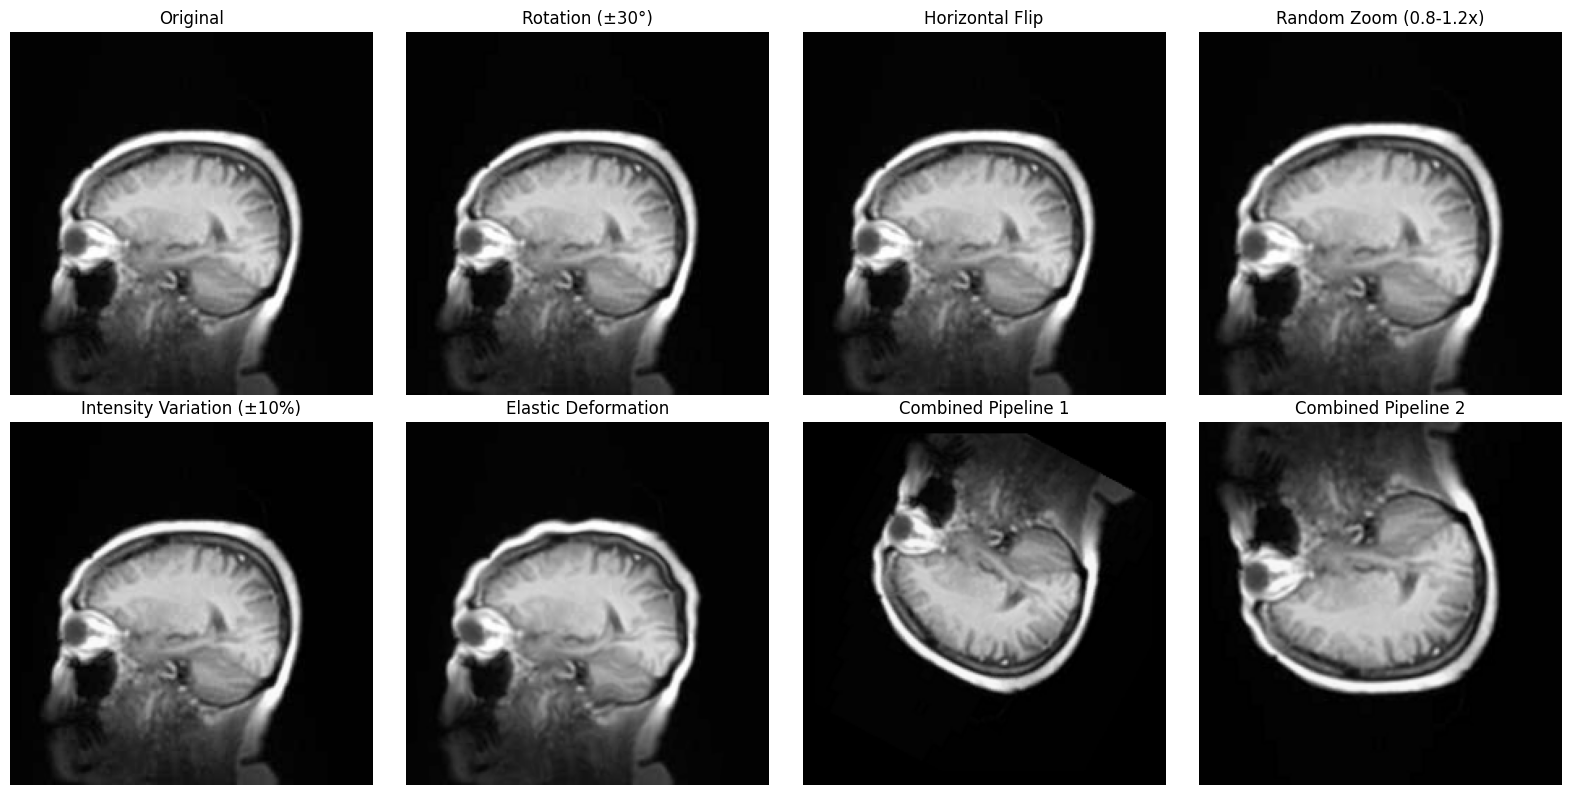


✓ Augmentation pipeline ready for training

Augmentation techniques implemented:
  1. Rotation: ±30 degrees
  2. Horizontal/Vertical flipping
  3. Random zoom: 0.8-1.2x scale
  4. Intensity variation: ±10%
  5. Elastic deformation (for segmentation)

These augmentations enhance domain generalization by:
  - Increasing data variability
  - Simulating scanner differences
  - Improving model robustness


In [56]:
# Demonstrate individual augmentations
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Original
axes[0, 0].imshow(original_img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

# Rotation
rotated = augment_rotation(original_img, angle_range=(-30, 30))
axes[0, 1].imshow(rotated, cmap='gray')
axes[0, 1].set_title('Rotation (±30°)')
axes[0, 1].axis('off')

# Flip
flipped = augment_flip(original_img.copy(), horizontal=True, vertical=False)
axes[0, 2].imshow(flipped, cmap='gray')
axes[0, 2].set_title('Horizontal Flip')
axes[0, 2].axis('off')

# Zoom
zoomed = augment_zoom(original_img, zoom_range=(0.8, 1.2))
axes[0, 3].imshow(zoomed, cmap='gray')
axes[0, 3].set_title('Random Zoom (0.8-1.2x)')
axes[0, 3].axis('off')

# Intensity variation
intensity_varied = augment_intensity(original_img, intensity_range=(0.9, 1.1))
axes[1, 0].imshow(intensity_varied, cmap='gray')
axes[1, 0].set_title('Intensity Variation (±10%)')
axes[1, 0].axis('off')

# Elastic deformation
elastic_img = np.array(original_img)
elastic_deformed = augment_elastic_deform(elastic_img, alpha=30, sigma=5)
axes[1, 1].imshow(elastic_deformed.astype(np.uint8), cmap='gray')
axes[1, 1].set_title('Elastic Deformation')
axes[1, 1].axis('off')

# Combined augmentation pipeline (without elastic)
augmented1 = apply_augmentation_pipeline(original_img, {
    'rotation': True,
    'flip': True,
    'zoom': True,
    'intensity': True,
    'elastic': False
})
axes[1, 2].imshow(augmented1, cmap='gray')
axes[1, 2].set_title('Combined Pipeline 1')
axes[1, 2].axis('off')

# Another random combination
augmented2 = apply_augmentation_pipeline(original_img, {
    'rotation': True,
    'flip': True,
    'zoom': True,
    'intensity': True,
    'elastic': False
})
axes[1, 3].imshow(augmented2, cmap='gray')
axes[1, 3].set_title('Combined Pipeline 2')
axes[1, 3].axis('off')

plt.tight_layout()
plt.show()

print("\n✓ Augmentation pipeline ready for training")
print("\nAugmentation techniques implemented:")
print("  1. Rotation: ±30 degrees")
print("  2. Horizontal/Vertical flipping")
print("  3. Random zoom: 0.8-1.2x scale")
print("  4. Intensity variation: ±10%")
print("  5. Elastic deformation (for segmentation)")
print("\nThese augmentations enhance domain generalization by:"
      "\n  - Increasing data variability"
      "\n  - Simulating scanner differences"
      "\n  - Improving model robustness")